# ACTIVIDAD 5

## EDA

Lo que estamos haciendo en esta sección es entender todos los datos. Y resviar que todos los datos esten correctamente estructurados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("Heart Prediction Quantum Dataset.csv")

In [3]:
df.describe()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,54.864000,0.468000,132.874000,221.50000,88.766000,8.317407,0.600000
std,14.315004,0.499475,26.418516,43.86363,17.417289,0.919629,0.490389
min,30.000000,0.000000,90.000000,150.00000,60.000000,6.164692,0.000000
25%,43.000000,0.000000,111.000000,183.75000,73.000000,7.675779,0.000000
50%,55.000000,0.000000,132.000000,221.00000,89.000000,8.323064,1.000000
75%,66.250000,1.000000,155.000000,258.00000,104.000000,8.935999,1.000000
max,79.000000,1.000000,179.000000,299.00000,119.000000,10.784886,1.000000


In [4]:
df.drop(columns=['QuantumPatternFeature'], inplace=True)

<function matplotlib.pyplot.show(close=None, block=None)>

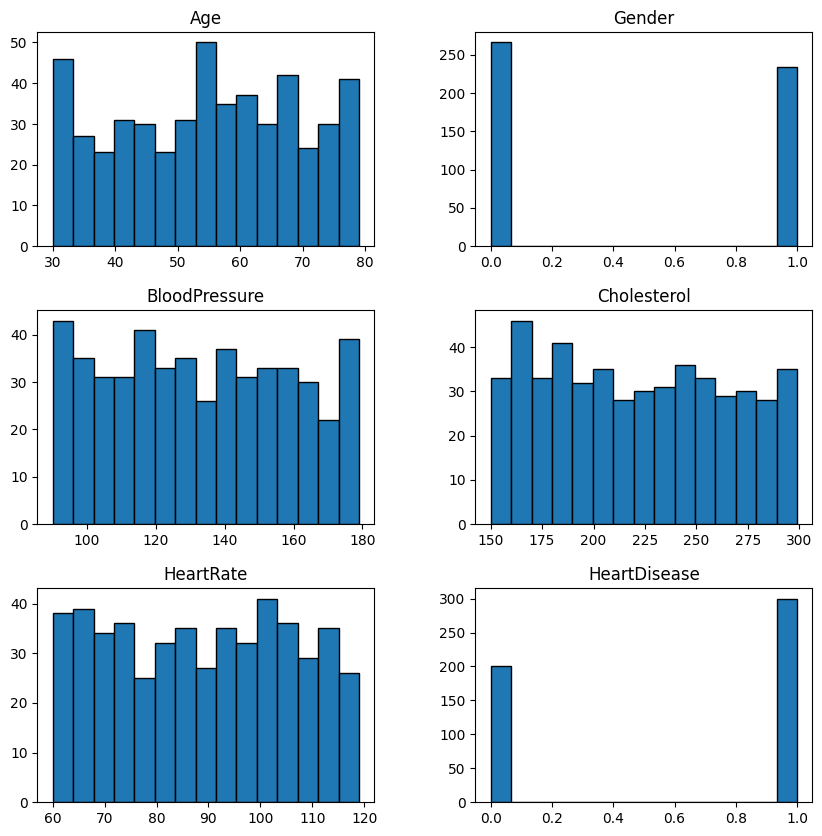

In [5]:
# 2. Seleccionar las columnas (excluyendo la de "Quantum")
cols_to_plot = [col for col in df.columns]

# 3. Crear los histogramas en una sola cuadrícula
df[cols_to_plot].hist(bins=15, figsize=(10, 10), grid=False, edgecolor = 'black')

plt.show

## Proceso para saber sobre el heart disease

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Definir las características numéricas y categóricas
numerical = ['Age', 'BloodPressure', 'Cholesterol', 'HeartRate']
categorical = ['Gender']

# Separar características (X) y variable objetivo (y)
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

# Creamos el preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical),        # Escala los números
        ('cat', OneHotEncoder(), categorical)
    ])

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(hidden_layer_sizes=(5,10), random_state=42))
])

pipeline.fit(X, y)


C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,hidden_layer_sizes,"(5, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001


In [7]:
pipeline.score(X, y)

0.8

In [8]:
from sklearn.model_selection import cross_val_score, KFold
cv = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ASUS\AppDa

In [12]:
from sklearn.model_selection import GridSearchCV

# Definimos en una libreria las tres opciones que tenemos para hidden_layer_sizes
param_grid = {
    'model__hidden_layer_sizes': [(2, 6), (5, 15), (3, 6)]
}

# Utilizamos Pipeline para encadenar el preprocesamiento y el modelo
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(random_state=42, max_iter=500))
])

# Usamos GridSearchCV para encontrar la mejor combinación de hiperparámetros
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=10,
    scoring='roc_auc'
)

# Ajustamos los datos ('X' y 'y')
grid.fit(X, y)

# Imprimimos los mejores hiperparámetros y el mejor score
print(f"La mejor combinación es: {grid.best_params_}")
print(f"Mejor score (ROC-AUC): {grid.best_score_:.4f}")

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ASUS\AppDa

La mejor combinación es: {'model__hidden_layer_sizes': (5, 15)}
Mejor score (ROC-AUC): 0.8485
